# VLA spectral line tutorial
- by Brian Svoboda (NRAO) for the [9th VLA Data Reduction Workshop](https://science.nrao.edu/science/meetings/2022/vla-data-reduction)

## Outline
* System configuration and CASA installation.
* Using this notebook.
* Using the documentation: https://casadocs.readthedocs.io
* Considerations for calibration and imaging of spectral lines
* Calibration of IRC+10216 data
* Imaging of IRC+10216 data
* Scripting CASA for user-developed pipelines

## A note on Jupyter notebooks
The principal advantage of Jupyter notebooks are that they enable the mixing of executable code and well-formatted prose explanation. This is similar to the concept of [literate programming](https://en.wikipedia.org/wiki/Literate_programming), a programming paradigm developed by Donald Knuth (of $\TeX$ fame!). With this notebook one should be able to fully calibrate the an example dataset using CASA as well as reproduce all of the relevant plots and images (the latter with help from an image viewer such as [CARTA](https://cartavis.org/)). One may also experiment, modify the code, and add new *cells* to explore the dataset using CASA and the Python tools available on your system.

Note that all cells are evaluated at global scope. Be mindful that re-assigning a new value to a variable may affect other cells using that variable.

For more in-depth analysis and the development of project specific pipelines, one may find it advantageous to split out blocks of Python code into separate `.py` files (Python modules) and import these from either the notebook, the CASA shell, or one's preferred environment.

## System configuration and installation
To run this tutorial yourself, one may install the necessary packages into (1) the system's global Python environment, (2) the system's local user Python envorinment, or (3) a project specific virtual environment.

Option 1 is generally discouraged as it may break operating system's Python environment and applications that depend upon it. Option 2 is straightforward, but can lead to potential package conflicts and maintainance issues. The last, Option 3, is the safest in terms of ensuring that packages in one's Python environment do not conflict with each other and that the environment can be reproduced at a later date. This is especially useful for (a) making use of the latest libraries in new projects while (b) ensuring that past projects continue to work using a fixed set of libraries. For example, one can use a specific version of CASA just for this guide. To create a virtual environment for this tutorial, run from the terminal/bash:

```bash
# Create a virtual environment named `specline_tutorial.venv` in
# the current directory.
python3 -m venv specline_tutorial.venv

# Activate the Python environment (now empty) of that environment.
source specline_tutorial.venv/bin/activate

# Install Python modules and CASA libraries
pip install numpy astropy matplotlib
pip install casatasks casatools casadata casaplotms
```

To instead install these packages into the user's (global) Python environment, simply run the above pip commands with the `--user` flag as `pip install --user <...>`. Note that a drawback of the `venv` standard library module of Python is that it is tied to a specific version of Python (e.g., v3.8). The [`anaconda`](https://www.anaconda.com/products/distribution) and [`mamba`](https://mamba.readthedocs.io/en/latest/) projects are useful for managing multiple versions of Python and their environments.

Using `anaconda`, one can create an environment with Python 3.8 (compatible with the current CASA packages).

```bash
conda create --name casa_env -c anaconda python3.8
conda activate casa_env
pip install casatasks casatools casadata casaplotms
pip install numpy astropy matplotlib
```

## Imports
Below we import the necessary Python packages and check whether the code is being executed within the notebook or copy-pasted into a CASA shell.

By calling `import casatasks as tasks`, we keep all task function names in the `tasks` module/namespace. We thus call tasks by appending a `.` and the task name; e.g., to call `importasdm` as is done further below, we call it as `tasks.importasdm`. This is considered good practice in Python programming because it makes it straightforward to identify where variables or functions originate from.

For ease of typing, one can drop this convention and import all CASA tasks into the global namespace by calling `from casatasks import *`.

In [49]:
import sys
if sys.version_info < (3, 0, 0):
    raise RuntimeError("This CASA notebook must be run under Python v3.")

import shutil
from pathlib import Path
from matplotlib import pyplot as plt

try:
    casalog.version
    is_running_within_casa = True
except NameError:
    is_running_within_casa = False

import casadata
import casatasks as tasks
import casatools
import casaplotms
import casalogger

if not is_running_within_casa:
    # If we are not in a "monolithic" CASA environment, import
    # toolkits with matching names and start the CASA logger.
    from casaplotms import plotms
    msmd = casatools.msmetadata()
    logger = casalogger.casalogger()

E0924 13:17:40.024765373   97421 fork_posix.cc:70]           Fork support is only compatible with the epoll1 and poll polling strategies


Note that after running the above cell, the CASA logger window should appear.

In [2]:
casa_version = '.'.join(str(n) for n in tasks.version())
print(f"CASA version: {casa_version}")

CASA version: 6.5.3.28


## Converting the SDM-BDF to an MS
Raw data written to the archive by VLA is stored in the "Science Data Model" (SDM) format. The SDM file stores metadata, such as spectral window configuration information, and encapsulates the raw visibility data stored in the BDF format. The combination of these two file formats are called an "SDM-BDF". An SDM-BDF is in practice a directory containing many text files (mainly XML) and binary data tables.

In order to manipulate our data in CASA, we must convert the SDM-BDF into a Measurement Set (MS) using the task [`importasdm`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.data.importasdm.html). Note that underlined tasknames in this guide are hyperlinks to the documentation on https://casadocs.readthediocs.io . In the call to `importasdm` we set the parameter `ocorr_mode="co"` to select cross-correlation data (and disregard the auto-correlations), and set `applyflags=True` to automatically apply "online" flags, i.e., ones known to the online system such as when the antenna is slewing and not on source. We set `lazy=True` to avoid copying/duplicating the data from the BDF into the MS by instead storing a reference. This saves storage space and improves IO performance for some tasks, but does mean that the reference must be updated (using the `ms.asdmref` toolkit function) if the SDM-BDF file is moved to a new location.

Note that the task `importevla` (with "e") is deprecated in favor of `importasdm`. Historical VLA observations should use the task [`importvla`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.data.importvla.html) (without "e").

Below, we assign file names to variables. The SDM-BDF has been renamed to `TDRW0001` and we have chosen the name `drw-all.ms` for our output MS. This may take a few moments.

In [83]:
asdm = "TDRW0001"
vis_base = "drw-all.ms"
vis_reduced = "reduced_10s.ms"
vis_prior = f"{vis_reduced}.prior"
vis_target = "irc10216.ms"
vis_contsub = f"{vis_target}.contsub"

In [85]:
if Path(vis_base).exists():
    shutil.rmtree(vis_base)
if Path(f"{vis_base}.flagversions").exists():
    shutil.rmtree(f"{vis_base}.flagversions")

tasks.importasdm(
    asdm=asdm,
    vis=vis_base,
    ocorr_mode="co",
    with_pointing_correction=True,
    applyflags=True,
    flagbackup=False,
    lazy=True,
)

## Flagging known bad data
Here we apply deterministic flags or "online" flags using the task [`flagdata`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.flagging.flagdata.html). These are also performed by the [calibration pipeline](https://science.nrao.edu/facilities/vla/data-processing/pipeline) task `hifv_flagdata`, among others. We flag visibilities for shadowed antennas, small time-ranges at the beginning of each scan, and zero-valued points. We do not save these flagging operations (setting `flagbackup=False`) because we generally do not need to reverse the deterministic flags.

First flag visibilities from shadowed antennas.

In [86]:
tasks.flagdata(
    vis=vis_base,
    mode="shadow",
    flagbackup=False,
);

Next flag a small number of visibilities near the beginning of each scan.

In [87]:
tasks.flagdata(
    vis=vis_base,
    mode="quack",
    quackinterval=6.0,
    flagbackup=False,
);

Finally, clip all zero-valued data for all correlation products.

In [88]:
tasks.flagdata(
    vis=vis_base,
    mode="clip",
    correlation="ABS_ALL",
    clipzeros=True,
    flagbackup=False,
);

## Split and time average
To reduce the size of the dataset for the tutorial, we split out the spectral windows of interest (**2** and **3**), exclude the initial setup scans, and average the native 1 sec visibility integrations to 10 sec.

SpW IDs **0** and **1** are used for pointing calibration in X Band and SpW IDs **4** through **7** are wide-bandwidth windows optimized for continuum observations (2 MHz channel width and 128 MHz subband bandwidth). We also exclude setup and pointing calibration scans **1** through **4**, and select the "CORRECTED"/calibrated column, which becomes the "DATA" colum in the new measurement set.

Although the task [`split`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.manipulation.split.html) serves a similar purpose, we use the task [`mstransform`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.manipulation.mstransform.html) here in order to perform the time averaging (`split` is primarily a specialized wrapper for `mstransform`).

In [90]:
if Path(vis_reduced).exists():
    shutil.rmtree(vis_reduced)
if Path(f"{vis_reduced}.flagversions").exists():
    shutil.rmtree(f"{vis_reduced}.flagversions")

tasks.mstransform(
    vis=vis_base,
    outputvis=vis_reduced,
    timeaverage=True,
    timebin="10s",
    spw="2~3",
    scan="5~59",
    datacolumn="data",
    keepflags=False,
)

## Listing observation information
With an MS file (`reduced_10s.ms`) generated from the SDM-BDF, we print general information on the observation using the [`listobs`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.information.listobs.html) task.

In [13]:
listfile = f"{vis_reduced}.list.txt"

listobs_results = tasks.listobs(
    vis=vis_reduced,
    listfile=listfile,
    overwrite=True,
);

The results are also returned in a Python dictionary, here assigned to the variable `listobs_results`. Note that while information *can* be retrieved from this dictionary, it is generally better practice to use the `msmetadata` toolkit instead, e.g.:

In [14]:
# Note that while information *can* be retrieved from this dictionary, it is
# generally better practice to use the `msmetadata` toolkit instead. The
# try/finally pattern ensures that the file is closed even if an error
# occurs while we have it open.
try:
    msmd.open(vis_reduced)
    field_names = msmd.namesforfields()
    print("Field names: ", field_names)
finally:
    msmd.close();

Field names:  ['J0954+1743', 'IRC+10216', 'J1229+0203', '1331+305=3C286']


The file generated by `listobs` can be inspected with one's text editor of choice but the file contents are printed here for completeness.

In [15]:
# Print contents of listobs output file.
def print_file(name):
    with open(name, "r") as f:
        print(f.read())

print_file(listfile)

           MeasurementSet Name:  /lustre/aoc/sciops/bsvoboda/casa_guides/irc_10216/reduced_10s.ms      MS Version 2
   Observer: Dr. Emmanuel Momjian     Project: uid://evla/pdb/35621723  
Observation: EVLA
Data records: 472674       Total elapsed time = 10038 seconds
   Observed from   07-Nov-2018/10:56:15.0   to   07-Nov-2018/13:43:33.0 (UTC)

   ObservationID = 0         ArrayID = 0
  Date        Timerange (UTC)          Scan  FldId FieldName             nRows     SpwIds   Average Interval(s)    ScanIntent
  07-Nov-2018/10:56:15.0 - 10:58:03.0     5      0 J0954+1743                6318  [0,1]  [11.5, 11.5] [CALIBRATE_AMPLI#UNSPECIFIED,CALIBRATE_PHASE#UNSPECIFIED]
              10:58:15.0 - 11:03:03.0     6      1 IRC+10216                16848  [0,1]  [11.9, 11.9] [OBSERVE_TARGET#UNSPECIFIED]
              11:03:15.0 - 11:04:33.0     7      0 J0954+1743                4862  [0,1]  [10.9, 10.9] [CALIBRATE_AMPLI#UNSPECIFIED,CALIBRATE_PHASE#UNSPECIFIED]
              11:04:45.0 - 11:0

If this were our own project we would likely know our observing setup and which targets are to be used for which calibration procedures. Here, we can use the scan intents to identify the field names of our calibrators. For example, 3C286 (1331+305) is the flux scale calibrator with the intent `[CALIBRATE_FLUX#UNSPECIFIED]`. We assign the field names to variables for later use.

In [4]:
field_gain      = "J0954+1743"      # complex gain calibrator
field_target    = "IRC+10216"       # science target
field_bandpass  = "J1229+0203"      # bandpass calibrator
field_flux      = "1331+305=3C286"  # flux calibrator
calibrator_fields = f"{field_gain},{field_bandpass},{field_flux}"

## Data inspection
Now that we have applied deterministic flags and calibration steps, we inspect the data using [`plotants`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.visualization.plotants.html) and [`plotms`](https://casadocs.readthedocs.io/en/stable/api/tt/casaplotms.plotms.html) to investigate if any data needs to be flagged before further calibration.

In [17]:
tasks.plotants(
    vis=vis_reduced,
    figfile="antpos_logspacing.png",
    antindex=True,
    logpos=True,
    showgui=False,
)

In [18]:
tasks.plotants(
    vis=vis_reduced,
    figfile="antpos_linspacing.png",
    antindex=True,
    logpos=False,
    showgui=False,
)
# Fiddle with the plot to make the X and Y axes have equal aspect ratio
ax = plt.gca()  # "get current axis"
ax.set_aspect("equal")

The antenna **ea08** looks like a good reference antenna to choose (assuming we find no issues when inspecting the visibilities below) because it is near the center of the array. It is also unlikely to have issues with shadowing because it is the furthest south among nearby the antennas.

In [5]:
refant = "ea08"

We now begin inspecting the data in terms of time, elevation, frequency, *uv*-distance, and *uv*-amplitude to look for outliers. We assign variables below for spectral window selection excluding the outer three edge channels (0 to 3 and 61 to 64).

(**TODO** Would it be simpler to split edge channels out at the `mstransform` step?)

In [6]:
all_spw = "0~1:3~60"
spw0 = "0:3~60"
spw1 = "1:3~60"

n_chan_in_range = "58"
n_chan_per_spw = "64"

parallel_hands = "rr,ll"  # parallel hands, RR and LL correlations
long_time = "1e8"  # sec; effectively infinite

## Time and elevation plots
Below we begin inspecting our data using the [`plotms`](https://casadocs.readthedocs.io/en/stable/api/tt/casaplotms.plotms.html) viewer. The [Data Examination/Editing](https://casadocs.readthedocs.io/en/stable/notebooks/data_examination.html) CASA documentation page provides further references on using `plotms` to examine measurement sets and calibration tables, in addition to other tools for data inspection found in CASA.

The calls in this guide will open a seperate window for the `plotms` GUI (which may cause issues if one is working through a remote connection). [This](https://casadocs.readthedocs.io/en/stable/examples/community/jupyter_and_x11.html) CASA guide explores embedding `plotms` views into Jupyter notebook cells using a virtual framebuffer.

We first plot elevation versus time and amplitude versus time color-coded by field. Images are saved to the file system with the name set in the `plotfile` parameter.

In [64]:
plotms(
    vis=vis_reduced,
    xaxis="time",
    yaxis="elevation",
    correlation=parallel_hands,
    spw=all_spw,
    avgspw=True,
    avgchannel=n_chan_in_range,
    coloraxis="field",
    plotfile="uncal_Ex.png",
    highres=True,
    overwrite=True,
)

2023-03-31 22:34:34	WARN	MSTransformManager::checkDataColumnsToFill	No datacolumn selected in buffer mode


In [65]:
plotms(
    vis=vis_reduced,
    xaxis="time",
    yaxis="amp",
    correlation=parallel_hands,
    spw=all_spw,
    avgspw=True,
    avgchannel=n_chan_in_range,
    coloraxis="field",
    plotfile="uncal_Tx.png",
    highres=True,
    overwrite=True,
)

## Generate prior calibrations
Here we apply known calibration steps, such as for antenna position offsets (`antpos`), antenna gain-curve (`gc`), atmospheric opactiy (`opac`), and requantizer gains (not needed for this dataset). We generate calibration tables (e.g., `cal.ant` file) with [`gencal`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.calibration.gencal.html) and then apply the solutions with [`applycal`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.calibration.applycal.html).

We also use the [`plotweather`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.visualization.plotweather.html) task to determine the atmospheric opacity for each SPW from measured and historical data.

In [21]:
# Calculate antenna position offsets
tasks.gencal(
    vis=vis_reduced,
    caltable="cal.ant",
    caltype="antpos",
    antenna="",
);

In [22]:
# This step requires files for the elevation gain curves to be installed
# through the `casadata` package and a link to the directory containg
# the files.
# note, `caltype` from "gceff" to "gc" since efficiences on the VLA
# are not well known.
tasks.gencal(
    vis=vis_reduced,
    caltable="cal.gc",
    caltype="gc",
);

In [24]:
# Calculate measured and model based opacities and plot weather data
opacity = tasks.plotweather(
    vis=vis_reduced,
    plotName="weather.png",
)
opacity

[0.04061505896043428, 0.04085016638355082]

![weather](weather.png)

In [25]:
# Calculate gain table from opacity estimates.
tasks.gencal(
    vis=vis_reduced,
    caltable="cal.tau",
    caltype="opac",
    spw="0~1",
    parameter=opacity,
);

In [26]:
# Apply calibration tables to the measurement set.
tasks.applycal(
    vis=vis_reduced,
    gaintable=["cal.ant", "cal.gc", "cal.tau"],
    flagbackup=False,
);

In [29]:
# Split measurement set out to convert "corrected" into "data" column
if Path(vis_prior).exists():
    shutil.rmtree(vis_prior)
    shutil.rmtree(f"{vis_prior}.flagversions")

tasks.split(
    vis=vis_reduced,
    outputvis=vis_prior,
    datacolumn="corrected",
)

## Amplitude versus *uv*-distance
Plot amplitude versus *uv*-distance for our target and calibrators. Look for any systematically high or low outliers. One can draw a selection around such points and use the "locate" (hour-glass over the white box) to identify if there is a common antenna, IF, etc.

In [19]:
for field in field_names:
    plotms(
        vis=vis_prior,
        field=field,
        xaxis="uvdist",
        yaxis="amp",
        correlation=parallel_hands,
        avgchannel=n_chan_in_range,
        coloraxis="spw",
        plotfile=f"uncal_{field}_Dx.png",
        highres=True,
        overwrite=True,
    )
    input(f"Inspect Field ID {field}: Press [Enter] to continue. ")

No more iterations.
No more iterations.
Inspect Field ID J0954+1743: Press [Enter] to continue. 
Inspect Field ID IRC+10216: Press [Enter] to continue. 
Inspect Field ID J1229+0203: Press [Enter] to continue. 
Inspect Field ID 1331+305=3C286: Press [Enter] to continue. 


We find that the flux calibrator (3C286) has some low-lying outliers. Inspecting these points with the "locate" tool we find that they all originate from times `2018/11/07/13:38:54` to `2018/11/07/13:39:00`.

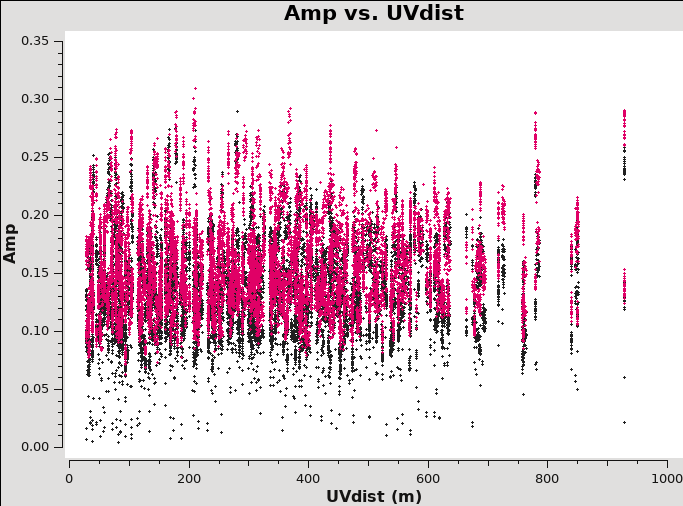

Below we flag a short time interval (a couple seconds) around this point. Because we have already averaged our MS down to 10 second integrations, any visibility containing that interval will be flagged. Note that in the call to `flagdata` we do not set the `flagbackup` parameter. We use the default value of `True` in the event we wish to roll-back this operation further on in the calibration.

In [30]:
tasks.flagdata(
    vis=vis_prior,
    timerange="13:38:54~13:39:05",
);

We see a similar pattern of low amplitudes over a short time interval on the bandpass calibrator, J1229+0203, so we flag this time-range as well.

In [31]:
tasks.flagdata(
    vis=vis_prior,
    timerange="13:30:25~13:30:35",
);

In [23]:
plotms(
    vis=vis_prior,
    field=field_flux,
    xaxis="uvdist",
    yaxis="amp",
    correlation=parallel_hands,
    avgchannel=chan_per_spw,
    coloraxis="spw",
    plotfile=f"uncal_{field_flux}_Dx_flagged.png",
    highres=True,
    overwrite=True,
)

The flagging operation was successful in removing the points:

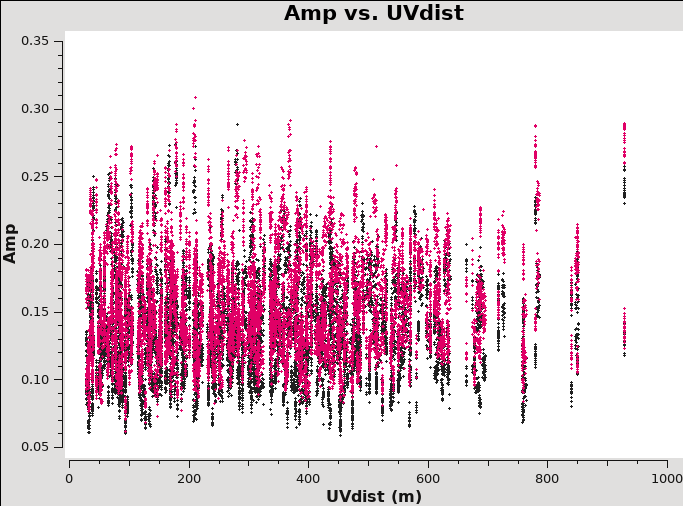

## Amplitude versus frequency
We now plot amplitude versus frequency for our target and calibrators. RFI will tend to be obvious as high-lying outliers clustered around certain frequency ranges, although this Ka Band dataset, as is typical for most high-frequency observations, does not appear to be affected by RFI. Note that strong astronomical spectral lines may appear similar to RFI in these plots.

These two-subbands happen to be close in frequency (~36.31 and ~36.40 GHz) so they are straight-forward to plot simultaneously on the same frequency axis. More complex spectral configurations will benefit by iterating over each SpW using `iteraxis="spw"` for interactive use or looping over each SpW ID using `spw="<ID>"` when statically generating plots.

In [24]:
for field in field_names:
    plotms(
        vis=vis_prior,
        field=field,
        xaxis="freq",
        yaxis="amp",
        correlation=parallel_hands,
        coloraxis="corr",
        plotfile=f"uncal_{field}_Fx.png",
        highres=True,
        overwrite=True,
    )
    input(f"Inspect Field ID {field}: Press [Enter] to continue. ")

Inspect Field ID J0954+1743: Press [Enter] to continue. 
Inspect Field ID IRC+10216: Press [Enter] to continue. 
Inspect Field ID J1229+0203: Press [Enter] to continue. 
Inspect Field ID 1331+305=3C286: Press [Enter] to continue. 


In general based on our findings above from the *uv*-distance and frequency diagnostic plots, one may wish to inspect individual antennas or spectral windows in more detail. Aside from flagging the short time range around `13:39:54`, this dataset appears otherwise well-behaved.

# Set flux scale

To verify that CASA can find the flux calibrator models, we use the `listmodels=True` parameter in the [`setjy`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.imaging.setjy.html) task. `3C286_A.im` (3C286 at Ka Band) should be present.

In [32]:
tasks.setjy(
    vis=vis_prior,
    listmodels=True,
);

common.image
IRC+10216_HC3N_clean_am.image
IRC+10216_HC3N_clean_am.model
IRC+10216_HC3N_clean.image
IRC+10216_HC3N_clean.model
IRC+10216_HC3N_dirty.image
IRC+10216_HC3N_dirty.model
smoothed.image
test_pv.image
3C123_P.im
3C138_A.im
3C138_C.im
3C138_K.im
3C138_L.im
3C138_P.im
3C138_Q.im
3C138_S.im
3C138_U.im
3C138_X.im
3C147_A.im
3C147_C.im
3C147_K.im
3C147_L.im
3C147_P.im
3C147_Q.im
3C147_S.im
3C147_U.im
3C147_X.im
3C196_P.im
3C286_A.im
3C286_C.im
3C286_K.im
3C286_L.im
3C286_P.im
3C286_Q.im
3C286_S.im
3C286_U.im
3C286_X.im
3C295_P.im
3C380_P.im
3C48_A.im
3C48_C.im
3C48_K.im
3C48_L.im
3C48_P.im
3C48_Q.im
3C48_S.im
3C48_U.im
3C48_X.im
README


In [34]:
setjy_results = tasks.setjy(
    vis=vis_prior,
    field=field_flux,
    model="3C286_A.im",
    scalebychan=True,
    usescratch=True,
)

We can see the results from `setjy` in the returned dictionary or in the output of the CASA logger. This is a model derived value and gives the expected Stokes I (total intensity) value for 3C286 in both spectral windows, here both about 1.75 Jy at ~36 GHz.

## Inspect bandpass calibrator
Before determining the bandpass solution, we inspect the phase and amplitude variations with time and frequency on the bandpass calibrator in order to decide how best to proceed. The phases should not vary significantly by channel and the variations in phase with time should be modest. We first inspect the phases versus channel for one baseline (`ea08&ea13`):

In [12]:
plotms(
    vis=vis_prior,
    field=field_bandpass,
    xaxis="channel",
    yaxis="phase",
    correlation=parallel_hands,
    avgtime=long_time,
    spw=spw0,
    antenna=f"{refant}&ea13",
)

And now inspect all baselines for both spectral windows:

In [14]:
for i, spw in enumerate((spw0, spw1)):
    plotms(
        vis=vis_prior,
        field=field_bandpass,
        xaxis="channel",
        yaxis="phase",
        antenna=refant,
        correlation=parallel_hands,
        avgtime=long_time,
        spw=spw,
        coloraxis="antenna2",
        iteraxis="corr",
        plotfile=f"uncal_{field_bandpass}_chan_phase_spw{i}.png",
        highres=True,
        overwrite=True,
    )
    input(f"Inspect SpW {spw[0]}: Press [Enter] to continue. ")

Inspect SpW 0: Press [Enter] to continue. 
Inspect SpW 1: Press [Enter] to continue. 


We next inspect the amplitudes versus channel:

In [17]:
for i, spw in enumerate((spw0, spw1)):
    plotms(
        vis=vis_prior,
        field=field_bandpass,
        xaxis="channel",
        yaxis="amp",
        antenna=refant,
        correlation=parallel_hands,
        avgtime=long_time,
        spw=spw,
        coloraxis="antenna2",
        iteraxis="corr",
        plotfile=f"uncal_{field_bandpass}_chan_amp_spw{i}.png",
        highres=True,
        overwrite=True,
    )
    input(f"Inspect SpW {spw[0]}: Press [Enter] to continue. ")

Inspect SpW 0: Press [Enter] to continue. 
Inspect SpW 1: Press [Enter] to continue. 


We next inspect phase versus time:

In [20]:
for i, spw in enumerate((spw0, spw1)):
    plotms(
        vis=vis_prior,
        field=field_bandpass,
        xaxis="time",
        yaxis="phase",
        antenna=refant,
        correlation=parallel_hands,
        avgchannel=n_chan_in_range,
        spw=spw,
        coloraxis="antenna2",
        iteraxis="corr",
        plotfile=f"uncal_{field_bandpass}_time_phase_spw{i}.png",
        highres=True,
        overwrite=True,
    )
    input(f"Inspect SpW {spw[0]}: Press [Enter] to continue. ")

Inspect SpW 0: Press [Enter] to continue. 
Inspect SpW 1: Press [Enter] to continue. 


And lastly we inspect amplitude versus time:

In [21]:
for i, spw in enumerate((spw0, spw1)):
    plotms(
        vis=vis_prior,
        field=field_bandpass,
        xaxis="time",
        yaxis="amp",
        antenna=refant,
        correlation=parallel_hands,
        avgchannel=n_chan_in_range,
        spw=spw,
        coloraxis="antenna2",
        iteraxis="corr",
        plotfile=f"uncal_{field_bandpass}_time_amp_spw{i}.png",
        highres=True,
        overwrite=True,
    )
    input(f"Inspect SpW {spw[0]}: Press [Enter] to continue. ")

Inspect SpW 0: Press [Enter] to continue. 
Inspect SpW 1: Press [Enter] to continue. 


## Calibrate bandpass and delay
We first perform delay calibration on the bandpass calibrator. The delay is the linear slope of phase across frequency. The delay calibration is an antenna based calibration solution and it can be derived in `gaincal` with parameter `gaintype="K"`. We store the solutions generated by `gaincal` into the calibration table ("caltable") `cal.dly`.

In [22]:
gaincal_results = tasks.gaincal(
    vis=vis_prior,
    field=field_bandpass,
    caltable="cal.dly",
    refant=refant,
    refantmode="strict",
    gaintype="K",  # solve for delay, "K" or "KCROSS"
)

2023-09-23 22:08:09	SEVERE	MeasTable::dUTC(Double) (file casacore/measures/Measures/MeasTable.cc, line 4292)	Leap second table TAI_UTC seems out-of-date.
2023-09-23 22:08:09	SEVERE	MeasTable::dUTC(Double) (file casacore/measures/Measures/MeasTable.cc, line 4292)+	Until the table is updated (see the CASA documentation or your system admin),
2023-09-23 22:08:09	SEVERE	MeasTable::dUTC(Double) (file casacore/measures/Measures/MeasTable.cc, line 4292)+	times and coordinates derived from UTC could be wrong by 1s or more.


{'apply_tables': array([], dtype='<U5'),
 'selectvis': {'antennas': array([ 0,  1,  6,  7, 13, 15, 16, 20, 25, 26]),
  'field': array([2]),
  'intents': array(['CALIBRATE_AMPLI#UNSPECIFIED', 'CALIBRATE_BANDPASS#UNSPECIFIED',
         'CALIBRATE_DELAY#UNSPECIFIED', 'CALIBRATE_FLUX#UNSPECIFIED',
         'CALIBRATE_PHASE#UNSPECIFIED', 'CALIBRATE_POINTING#ON_SOURCE',
         'OBSERVE_TARGET#UNSPECIFIED', 'SYSTEM_CONFIGURATION#UNSPECIFIED',
         'UNSPECIFIED#UNSPECIFIED'], dtype='<U32'),
  'observation': array([0]),
  'scan': array([56]),
  'spw': array([0, 1])},
 'solve_tables': array(['cal.dly'], dtype='<U7'),
 'solvestats': {'above_minblperant': array([2, 2]),
  'above_minsnr': array([2, 2]),
  'data_unflagged': array([2, 2]),
  'expected': array([2, 2]),
  'spw0': {'above_minblperant': array([1, 1]),
   'above_minsnr': array([1, 1]),
   'ant0': {'above_minblperant': array([1, 1]),
    'above_minsnr': array([1, 1]),
    'data_unflagged': array([1, 1]),
    'expected': array([1, 1])

We now inspect the solutions as delay versus frequency using `plotms`; the delays should only be a few nanoseconds. We use a grid view to display one plot for each antenna in 3 x 3 groups. The plots can be paged using the green arrows at the bottom of the `plotms` window to view the panels for all antennas.

In [40]:
plotms(
    vis="cal.dly",
    gridrows=3,
    gridcols=3,
    xaxis="freq",
    yaxis="delay",
    iteraxis="antenna",
    coloraxis="corr",
)

We now derive phase solutions for the bandpass calibrator. This is done by selecting `calmode="p"` for phase solutions and compute the solutions over short timescales near the integration time (10 sec). We use the delays derived above by passing the `cal.dly` table in the `gaintable` parameter. We store the solutions in the `cal.pbp` caltable with the ".pbp" mnemonic for "phase bandpass".

In [24]:
gaincal_results = tasks.gaincal(
    vis=vis_prior,
    field=field_bandpass,
    refant=refant,
    refantmode="strict",
    caltable="cal.pbp",
    calmode="p",
    spw=all_spw,
    solint="int",
    gaintable=["cal.dly"],
)

Found no unflagged data at:   (time=2018/11/07/13:30:27.0 field=2 spw=0 chan=0)
Found no unflagged data at:   (time=2018/11/07/13:30:30.0 field=2 spw=0 chan=0)
Found no unflagged data at:   (time=2018/11/07/13:30:33.0 field=2 spw=0 chan=0)
 Insufficient unflagged antennas to proceed with this solve.
   (time=2018/11/07/13:30:45.0 field=2 spw=0 chan=0)
 Insufficient unflagged antennas to proceed with this solve.
   (time=2018/11/07/13:30:57.0 field=2 spw=0 chan=0)
 Insufficient unflagged antennas to proceed with this solve.
   (time=2018/11/07/13:31:09.0 field=2 spw=0 chan=0)
 Insufficient unflagged antennas to proceed with this solve.
   (time=2018/11/07/13:31:21.0 field=2 spw=0 chan=0)
 Insufficient unflagged antennas to proceed with this solve.
   (time=2018/11/07/13:31:33.0 field=2 spw=0 chan=0)
 Insufficient unflagged antennas to proceed with this solve.
   (time=2018/11/07/13:31:45.0 field=2 spw=0 chan=0)
 Insufficient unflagged antennas to proceed with this solve.
   (time=2018/1

Inspect the resulting phase solutions as a function of time. The gains should vary coherently. Remember to page through all antennas.

In [26]:
plotms(
    vis="cal.pbp",
    gridrows=3,
    gridcols=3,
    xaxis="time",
    yaxis="phase",
    iteraxis="antenna",
    plotrange=[0, 0, -180, 180],
    coloraxis="corr",
    plotfile=f"uncal_{field_bandpass}_cal_pbp.png",
    highres=True,
    overwrite=True,
)

With good phase solutions in hand, we now derive bandpass solutions using the `bandpass` task by passing the calibration tables for the delays and phase variations (`cal.dly` and `cal.pbp`, respectively) and store the results in the new caltable `cal.bp`.

In [27]:
bandpass_results = tasks.bandpass(
    vis=vis_prior,
    field=field_bandpass,
    caltable="cal.bp",
    refant=refant,
    gaintable=["cal.dly", "cal.pbp"],
)

{'apply_tables': array(['cal.dly', 'cal.pbp'], dtype='<U7'),
 'selectvis': {'antennas': array([ 0,  1,  6,  7, 13, 15, 16, 20, 25, 26]),
  'field': array([2]),
  'intents': array(['CALIBRATE_AMPLI#UNSPECIFIED', 'CALIBRATE_BANDPASS#UNSPECIFIED',
         'CALIBRATE_DELAY#UNSPECIFIED', 'CALIBRATE_FLUX#UNSPECIFIED',
         'CALIBRATE_PHASE#UNSPECIFIED', 'CALIBRATE_POINTING#ON_SOURCE',
         'OBSERVE_TARGET#UNSPECIFIED', 'SYSTEM_CONFIGURATION#UNSPECIFIED',
         'UNSPECIFIED#UNSPECIFIED'], dtype='<U32'),
  'observation': array([0]),
  'scan': array([56]),
  'spw': array([0, 1])},
 'solve_tables': array(['cal.bp'], dtype='<U6'),
 'solvestats': {'above_minblperant': array([2, 2]),
  'above_minsnr': array([2, 2]),
  'data_unflagged': array([2, 2]),
  'expected': array([2, 2]),
  'spw0': {'above_minblperant': array([1, 1]),
   'above_minsnr': array([1, 1]),
   'ant0': {'above_minblperant': array([1, 1]),
    'above_minsnr': array([1, 1]),
    'data_unflagged': array([1, 1]),
    'expec

As with all applications of `gaincal`, we now inspect the solutions. Since this is the bandpass solution, we inspect the amplitude as a function of channel (or frequency) and inspect the results for all antennas. A smooth roll-off is to be expected at the edges of the subbands.

In [29]:
plotms(
    vis="cal.bp",
    gridrows=3,
    gridcols=3,
    xaxis="chan",
    yaxis="amp",
    iteraxis="antenna",
    coloraxis="corr",
    plotfile=f"uncal_{field_bandpass}_cal_bp_chan_amp.png",
    highres=True,
    overwrite=True,
)

Similarly, we inspect the phase versus channel. The trend should be fairly smooth with relatively low dispersion. Note that the reference antenna will be zero-valued by construction.

In [31]:
plotms(
    vis="cal.bp",
    gridrows=3,
    gridcols=3,
    xaxis="chan",
    yaxis="phase",
    iteraxis="antenna",
    coloraxis="corr",
    plotfile=f"uncal_{field_bandpass}_cal_bp_chan_phase.png",
    highres=True,
    overwrite=True,
)

## Gain calibration
Phase variations due to tropospheric changes in water vapor content decorrelates the visibilities for our calibrators. Notably this affects our absolute flux calibration on our flux calibrator. In the following steps we effectively self-calibrate our gain, flux, and bandpass calibrators.

Our first step is to calculate per integration (10 sec) phase solutions (`calmode="p"`) for all three calibrator fields (stored in the list `calibrator_fields` defined above) and store the results in the caltable `cal.ign` (mnemonic "integration"). We pass the delay and bandpass solutions in the `gaintable` argument.

In [32]:
gaincal_results = tasks.gaincal(
    vis=vis_prior,
    field=calibrator_fields,
    spw=all_spw,
    solint="int",
    caltable="cal.ign",
    calmode="p",
    refant=refant,
    refantmode="strict",
    gaintable=["cal.dly", "cal.bp"],
)

Found no unflagged data at:   (time=2018/11/07/13:30:29.8 field=2 spw=0 chan=0)
Found no unflagged data at:   (time=2018/11/07/13:30:29.8 field=2 spw=1 chan=0)
Found no unflagged data at:   (time=2018/11/07/13:38:58.6 field=3 spw=0 chan=0)
Found no unflagged data at:   (time=2018/11/07/13:38:58.6 field=3 spw=1 chan=0)


We inspect the phase solutions as a function of time. Ideally there should be no large discontinuities.

In [33]:
plotms(
    vis="cal.ign",
    gridrows=3,
    gridcols=3,
    xaxis="time",
    yaxis="phase",
    iteraxis="antenna",
    coloraxis="corr",
    plotrange=[0, 0, -180, 180],
    plotfile=f"gaincal_ign_time_phase.png",
    highres=True,
    overwrite=True,
)

While the per-integration solutions are of good quality and well-suited for application to the calibrators themselves, because the phase is interpolated using the individual end points of our gain calibrator scans when applying them to our target, non-negligible phase scatter will be introduced. For representative values used for phase referencing to the target, we integrate over the whole calibrator scan using the `solint="inf"` interval.

In [34]:
# Phase calibration of calibrators with an "inf" solution interval
# over individual scans (a  few minutes in this case).
gaincal_results = tasks.gaincal(
    vis=vis_prior,
    field=calibrator_fields,
    spw=all_spw,
    solint="inf",
    caltable="cal.sgn",
    calmode="p",
    refant=refant,
    refantmode="strict",
    gaintable=["cal.dly", "cal.bp"],
)

{'apply_tables': array(['cal.bp', 'cal.dly'], dtype='<U7'),
 'selectvis': {'antennas': array([ 0,  1,  2,  3,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26]),
  'field': array([0, 2, 3]),
  'intents': array(['CALIBRATE_AMPLI#UNSPECIFIED', 'CALIBRATE_BANDPASS#UNSPECIFIED',
         'CALIBRATE_DELAY#UNSPECIFIED', 'CALIBRATE_FLUX#UNSPECIFIED',
         'CALIBRATE_PHASE#UNSPECIFIED', 'CALIBRATE_POINTING#ON_SOURCE',
         'OBSERVE_TARGET#UNSPECIFIED', 'SYSTEM_CONFIGURATION#UNSPECIFIED',
         'UNSPECIFIED#UNSPECIFIED'], dtype='<U32'),
  'observation': array([0]),
  'scan': array([ 5,  7,  9, 11, 13, 15, 17, 19, 22, 24, 26, 28, 30, 32, 34, 36, 39,
         41, 43, 45, 47, 49, 51, 53, 56, 59]),
  'spw': array([0, 1])},
 'solve_tables': array(['cal.sgn'], dtype='<U7'),
 'solvestats': {'above_minblperant': array([52, 52]),
  'above_minsnr': array([52, 52]),
  'data_unflagged': array([52, 52]),
  'expected': array([52, 52]),
  'spw0': {'abo

In [39]:
# Inspect solutions.
# Note that relatively large jumps in phase may be due
# antennas with bad pointing, which were corrected at
# approximately hourly intervals.
plotms(
    vis="cal.sgn",
    gridrows=3,
    gridcols=3,
    xaxis="time",
    yaxis="phase",
    iteraxis="antenna",
    coloraxis="corr",
    plotrange=[0, 0, -180, 180],
    plotfile=f"gaincal_sgn_time_phase.png",
    highres=True,
    overwrite=True,
)

In [37]:
# Amplitude and phase calibration over "inf" interval (scan in this case).
gaincal_results = tasks.gaincal(
    vis=vis_prior,
    field=calibrator_fields,
    spw=all_spw,
    solint="inf",
    caltable="cal.gn",
    calmode="ap",
    refant=refant,
    refantmode="strict",
    gaintable=["cal.dly", "cal.bp", "cal.ign"],
)

In [42]:
# Inspect solutions.
# Hopefully solutions have reasonably low dispersion.
plotms(
    vis="cal.gn",
    gridrows=3,
    gridcols=3,
    xaxis="time",
    yaxis="phase",
    iteraxis="antenna",
    coloraxis="corr",
    plotrange=[0, 0, -10, 10],
    plotfile=f"gaincal_gn_time_phase.png",
    highres=True,
    overwrite=True,
)

In [43]:
# Note that the last two points are the bandpass and flux
# calibrators, which have different amplitudes than the
# gain calibrator (initial points).
plotms(
    vis="cal.gn",
    gridrows=3,
    gridcols=3,
    xaxis="time",
    yaxis="amp",
    iteraxis="antenna",
    coloraxis="corr",
    plotrange=[-1, -1, 0, 1],
    plotfile=f"gaincal_gn_time_amp.png",
    highres=True,
    overwrite=True,
)

## Calibrate flux scale and apply calibrations

Next we use the flux calibrator (whose flux density was set in `setjy` above) to derive the flux of the other calibrators. The flux table can be written as an incremental table, just like all other calibration tables. In that case it won't replace the `cal.gn` but both tables, `cal.gn` as well as `cal.flx` need to be carried onward. 

In [52]:
# We can inspect the flux values for our secondary calibrators
# in the logger or in the returned dictionary.
if Path("cal.flx").exists():
    shutil.rmtree("cal.flx")
    
flux = tasks.fluxscale(
    vis=vis_prior,
    caltable="cal.gn",
    fluxtable="cal.flx",
    reference=field_flux,
    incremental=True,
)

In [53]:
# nested dictionary indexed by:
#   - Field ID
#   - SpW ID
#   - the flux value field "fluxd"
#   - Stokes index
flux_gain = flux['0']['0']["fluxd"][0]
flux_bandpass = flux['2']['0']["fluxd"][0]

print(f"Flux {field_gain} (gain):      {flux_gain:2>2.3f} Jy")
print(f"Flux {field_bandpass} (bandpass): {flux_bandpass:2>2.3f} Jy")

Flux J0954+1743 (gain):      0.292 Jy
Flux J1229+0203 (bandpass): 15.231 Jy


Now we apply the calibration to each source with the derived tables and the appropriate source for that particular calibration. For the calibrators, all bandpass solutions are the same as for the bandpass calibrator, and the phase and amplitude calibration as derived from their own visibility data. 

In [54]:
# apply solutions to the gain calibrator
tasks.applycal(
    vis=vis_prior,
    field=field_gain,
    gaintable=["cal.dly", "cal.bp", "cal.ign", "cal.gn", "cal.flx"],
    gainfield=2*[field_bandpass] + 3*[field_gain],
    calwt=False,
)

In [55]:
# apply solutions to the bandpass calibrator
tasks.applycal(
    vis=vis_prior,
    field=field_bandpass,
    gaintable=["cal.dly", "cal.bp", "cal.ign", "cal.gn", "cal.flx"],
    gainfield=5*[field_bandpass],
    calwt=False,
)

In [56]:
# apply solutions to the flux calibrator
tasks.applycal(
    vis=vis_prior,
    field=field_flux,
    gaintable=["cal.dly", "cal.bp", "cal.ign", "cal.gn", "cal.flx"],
    gainfield=2*[field_bandpass] + 3*[field_flux],
    calwt=False,
)

We now apply the solutions to the target. Note that we change from the gain calibration derived on integration length intervals (`cal.ign`) to scan length intervals (`cal.sgn`) in the list passed to the `gaintable` parameter below.

In [57]:
# apply solutions to the target
tasks.applycal(
    vis=vis_prior,
    field=field_target,
    gaintable=["cal.dly", "cal.bp", "cal.sgn", "cal.gn", "cal.flx"],
    gainfield=2*[field_bandpass] + 3*[field_gain],
    calwt=False,
)

When inspecting the results, note that we now plot from the `ydatacolumn="corrected"` column and not `"data"`.

In [65]:
# inspect amplitude versus time for the gain calibrator
plotms(
    vis=vis_prior,
    xaxis="time",
    yaxis="amp",
    ydatacolumn="corrected",
    field=field_gain,
    avgchannel=n_chan_per_spw,
    iteraxis="antenna",
    correlation=parallel_hands,
    plotfile=f"cal_gain_time_amp.png",
    highres=True,
    overwrite=True,
)

In [64]:
# inspect amplitude versus time for the gain calibrator
plotms(
    vis=vis_prior,
    xaxis="time",
    yaxis="amp",
    ydatacolumn="corrected",
    field=field_flux,
    avgchannel=n_chan_per_spw,
    iteraxis="antenna",
    correlation=parallel_hands,
    plotfile=f"cal_flux_time_amp.png",
    highres=True,
    overwrite=True,
)

In [63]:
# inspect amplitude versus frequency for the gain calibrator
plotms(
    vis=vis_prior,
    xaxis="freq",
    yaxis="amp",
    ydatacolumn="corrected",
    spw=spw1,
    field=field_gain,
    coloraxis="corr",
    correlation=parallel_hands,
    plotfile=f"cal_gain_freq_amp.png",
    highres=True,
    overwrite=True,
)

In [66]:
# inspect amplitude versus uv-distance for the target
plotms(
    vis=vis_prior,
    xaxis="uvdist",
    yaxis="amp",
    ydatacolumn="corrected",
    field=field_target,
    avgchannel=n_chan_per_spw,
    coloraxis="antenna2",
    correlation=parallel_hands,
    plotfile=f"cal_target_uvdist_amp.png",
    highres=True,
    overwrite=True,
)

In [67]:
# inspect amplitude versus frequency for the target
# the line profile is visible in the average spectrum
plotms(
    vis=vis_prior,
    xaxis="freq",
    yaxis="amp",
    ydatacolumn="corrected",
    spw=spw1,
    field=field_target,
    coloraxis="corr",
    correlation=parallel_hands,
    plotfile=f"cal_target_freq_amp.png",
    highres=True,
    overwrite=True,
)

## Split out calibrated target data
We now use the task [`mstransfrom`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.manipulation.mstransform.html) to split out just our target data for further analysis and imaging.

In [69]:
if Path(vis_target).exists():
    shutil.rmtree(vis_target)

tasks.mstransform(
    vis=vis_prior,
    outputvis=vis_target,
    field=field_target,
    spw=all_spw,
    correlation=parallel_hands,
    keepflags=False,
)

In [71]:
# inspect resulting measurement set
# note, not necessary to specify target
plotms(
    vis=vis_target,
    xaxis="channel",
    yaxis="amp",
    correlation=parallel_hands,
    avgtime=long_time,
    avgscan=True,
    coloraxis="spw",
    plotfile=f"cal_target_chan_amp_avg.png",
    highres=True,
    overwrite=True,
)

## Continuum subtraction
In this case, we know that the target is moderately compact in the center of the field (the phase center), and thus [`uvcontsub`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.manipulation.uvcontsub.html) should be sufficient. The number of channels to exclude is based on the above `plotms` results.

In [76]:
if Path(vis_contsub).exists():
    shutil.rmtree(vis_contsub)

# This uses the new version of `uvcontsub` available in 6.5.2 onward.
# The old version of `uvcontsub` can be accessed via `uvcontsub_old`.
uvcontsub_results = tasks.uvcontsub(
    vis=vis_target,
    outputvis=vis_contsub,
    fitspec="0~1:3~13;46~60",
)

2023-09-24 23:51:29	WARN	MSSpw Expression parser::MSSpwIndex::convertToChannelIndex (file casacore/ms/MSSel/MSSpwIndex.cc, line 400)	Channel 60 out of range for SPW 0 (valid range 0~57). Limiting it to be within the available range.
2023-09-24 23:51:29	WARN	MSSpw Expression parser::MSSpwIndex::convertToChannelIndex (file casacore/ms/MSSel/MSSpwIndex.cc, line 400)	Channel 60 out of range for SPW 0 (valid range 0~57). Limiting it to be within the available range.Channel 60 out of range for SPW 1 (valid range 0~57). Limiting it to be within the available range.


{'description': 'summary of data fitting results in uv-continuum subtraction',
 'goodness_of_fit': {'field': {'0': {'scan': {'10': {'spw': {'0': {'polarization': {'0': {'chi_squared': {'average': {'imag': 16343554.0,
            'real': 16953310.0},
           'max': {'imag': 23337682.0, 'real': 32234100.0},
           'min': {'imag': 11379496.0, 'real': 8202073.5}},
          'count': 48},
         '1': {'chi_squared': {'average': {'imag': 16505516.0,
            'real': 16130991.0},
           'max': {'imag': 28188762.0, 'real': 21418022.0},
           'min': {'imag': 13416003.0, 'real': 7051102.5}},
          'count': 48}}},
       '1': {'polarization': {'0': {'chi_squared': {'average': {'imag': 16987186.0,
            'real': 17924618.0},
           'max': {'imag': 38105140.0, 'real': 17150936.0},
           'min': {'imag': 9811743.0, 'real': 8568481.0}},
          'count': 48},
         '1': {'chi_squared': {'average': {'imag': 15094791.0,
            'real': 14467595.0},
        

## Calculate weights
Compute and set weights based on variance of data using [`statwt`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.manipulation.statwt.html). Note that after splitting out the data, the CORRECTED was assigned to the DATA column in the new measurement set, which we use below in the call to `statwt`.

In [81]:
statwt_results = tasks.statwt(
    vis=vis_contsub,
    fitspw="0~1:14~45",
    excludechans=True,
    datacolumn="data",
)

....10....20....30....40....50....60....70....80....90....100%


And for the continuum measurement set:

In [114]:
statwt_results = tasks.statwt(
    vis=vis_target,
    fitspw="0~1:14~45",
    excludechans=True,
    datacolumn="data",
)

....10....20....30....40....50....60....70....80....90....100%


In [82]:
statwt_results

{'mean': 3.690310590010492, 'variance': 1.552118851940058}

## Regrid velocity axis
The VLA WIDAR correlator does not support Doppler *tracking*, but rather Doppler *setting* where the required sky frequency will be calculated at the beginning of the observation then fixed. Because the observations are made in the topocentric reference frame ("TOPO") narrow lines may shift as the fixed local-standard-of-rest ("LSRK") frequency shifts with respect to the topocentric frame. At 36 GHz a typical shift over the course of a six-hour observing track is approximately 0.4 km/s.

The `tclean` task performs on-the-fly conversion of frequency values from TOPO to LSRK when gridding the visibilities, but to perform self-calibration on a single channel of a very narrow-linewidth source this gridding must be done separately first such that the channels correspond to consistent LSRK frequency values. This frequency re-binning can be performed through the [`cvel2`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.manipulation.cvel2.html) task.

In [77]:
tasks.vishead(
    vis=vis_contsub,
    mode="summary",
)

Bin into ten channels with 5 km/s width for the HC3N line (spectral window ID 1).

In [79]:
vis_cvel = f"{vis_contsub}.cvel"
if Path(vis_cvel).exists():
    shutil.rmtree(vis_cvel)

tasks.cvel2(
    vis=vis_contsub,
    outputvis=vis_cvel,
    spw="1",
    mode="velocity",
    nchan=10,
    start="-50km/s",
    width="5km/s",
    restfreq="36.39232GHz",
    outframe="LSRK",
    veltype="optical",
)

2023-09-25 00:30:28	WARN	MSTransformManager::setup	There is only one selected SPW, no need to combine 


Inspect the output in the logger to see ten channels with a width of 606.974 kHz.

In [80]:
tasks.vishead(
    vis=vis_cvel,
    mode="summary",
)

## Imaging and deconvolution

### Create dirty image
We first create a dirty image of our target to measure the thermal noise in off-line channels and to give us a first look at the source structure adn help us evaluate what the best strategy is for deconvolution.

In [128]:
vis_contsub

'irc10216.ms.contsub'

In [130]:
restfreq_hc3n = "36.392238GHz"
restfreq_sis  = "36.309627GHz"

In [88]:
# Remove any existing images
for mol in ("HC3N", "SiS"):
    for ext in ("dirty", "clean", "clean_am"):
        tasks.rmtables(tablenames=f"{field_target}_{mol}_{ext}.*")

In [137]:
imagename_dirty = f"{field_target}_HC3N_dirty"
tasks.rmtables(f"{imagename_dirty}.*")
tasks.tclean(
    vis=vis_contsub,
    spw="1",
    imagename=imagename_dirty,
    imsize=[300, 300],
    cell="0.4arcsec",
    specmode="cube",
    outframe="LSRK",
    start=18,
    nchan=2,
    restfreq=restfreq_hc3n,
    perchanweightdensity=True,
    pblimit=-0.001,
    weighting="briggs",
    robust=0.5,
    niter=0,
    interactive=False,
);


0%....10....20....30....40....50....60....70....80....90....100%
2023-09-29 20:13:20	WARN	task_tclean::SIImageStore::restore (file src/code/synthesis/ImagerObjects/SIImageStore.cc, line 2247)	Restoring with an empty model image. Only residuals will be processed to form the output restored image.


It is also usually a good idea to take a look at the point-spread function (PSF). These observations were made over a fairly long three hour track and at medium to high elevation (~45-70 deg) and thus have a low-eccentricity main-lobe of the synthesized beam with the closest sidelobes at ~20% the main-lobe.

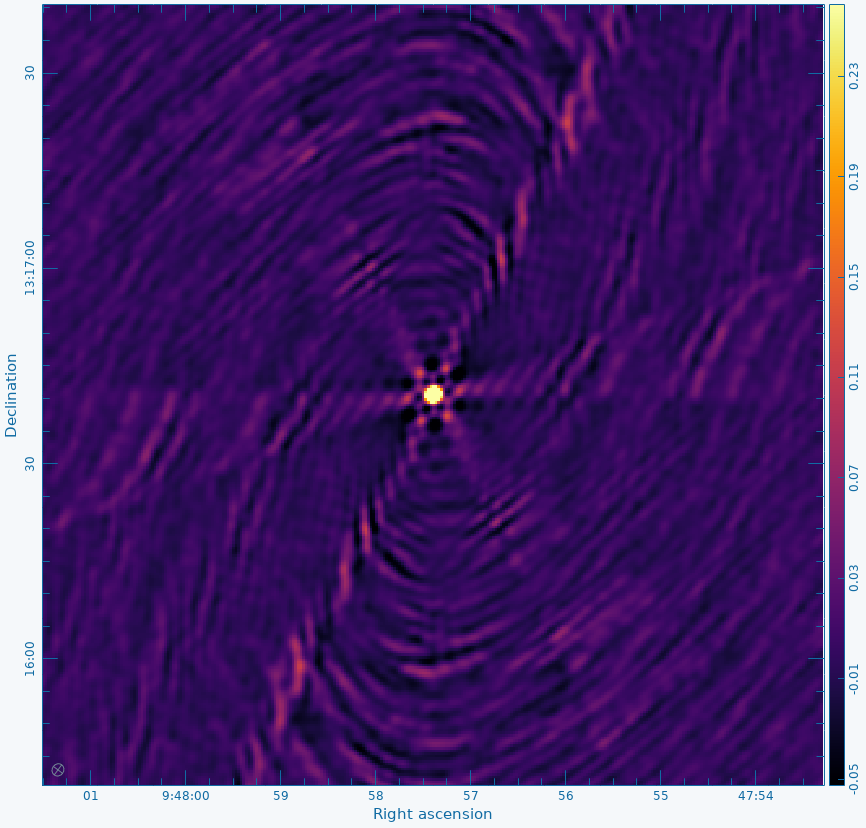

In [138]:
imagename_noise = f"{field_target}_HC3N_noise"
tasks.rmtables(f"{imagename_noise}.*")
tasks.tclean(
    vis=vis_contsub,
    spw="1",
    imagename=imagename_noise,
    imsize=[300, 300],
    cell="0.4arcsec",
    specmode="cube",
    outframe="LSRK",
    start=5,
    nchan=4,
    restfreq=restfreq_hc3n,
    perchanweightdensity=True,
    pblimit=-0.001,
    weighting="briggs",
    robust=0.5,
    niter=0,
    interactive=False,
);


0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%
2023-09-29 20:31:10	WARN	task_tclean::SIImageStore::restore (file src/code/synthesis/ImagerObjects/SIImageStore.cc, line 2247)	Restoring with an empty model image. Only residuals will be processed to form the output restored image.


We use the task [`imstat`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.information.imstat.html) to compute image statistics in an off-line channel selected after inspecting our dirty image generated above. The results are returned in a dictionary and we can access the root-mean-square deviation (RMS) through the `"rms"` key. For the HC$_3$N data, the noise appears to be about 1.0 mJy.

In [139]:
dirty_stats = tasks.imstat(
    imagename=f"{imagename_noise}.image",
)

rms = dirty_stats["rms"][0]
print(f"RMS: {1e3*rms:.6f} mJy")

RMS: 0.974642 mJy


### Interactive first-pass CLEAN
To remove the artifacts due to sparse-sampling in the *uv*-plane, we use the CLEAN algorithm implemented in the [`tclean`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.imaging.tclean.html) task to deconvolve our image. In the following example we CLEAN interactively by iteratively drawing the mask around significant emission.

In [141]:
# Ensure that any previous images open in viewers, etc., are closed.
imagename_interactive = f"{field_target}_HC3N_interactive"
tasks.rmtables(tablenames=f"{imagename_interactive}.*")
tasks.tclean(   
    vis=vis_contsub,
    spw="1",
    imagename=imagename_interactive,
    imsize=[300, 300],
    cell="0.4arcsec",
    specmode="cube",
    outframe="LSRK",
    start=19,
    nchan=1,
    restfreq=restfreq_hc3n,
    perchanweightdensity=True,
    pblimit=-0.001,
    weighting="briggs",
    robust=0.5,
    deconvolver="multiscale",
    scales=[0,5,15],
    threshold=f"{2*rms:.6f}Jy",
    niter=100_000,
    interactive=True,
);


0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%
2023-09-29 21:02:07	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging

0%....10....20....30....40....50....60....70....80....90....100%


CLEANing as deeply as one times the RMS requires fairly close attention that the CLEAN mask fits the source. Even if one intends to move on to the automated methods of creating the mask (see below), it is generally worth the effort to manually generate a CLEAN mask at least once to compare the generated masks against as a sort of "ground truth".

The following figure shows the restored image for channel index 22:

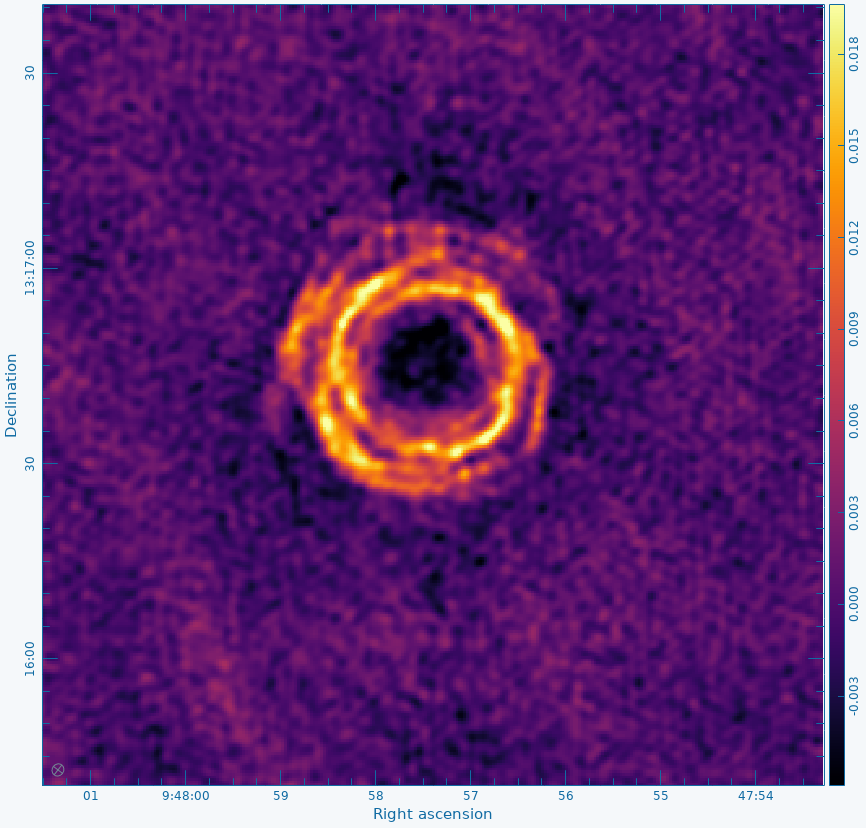

as well as the residual image for the same channel:

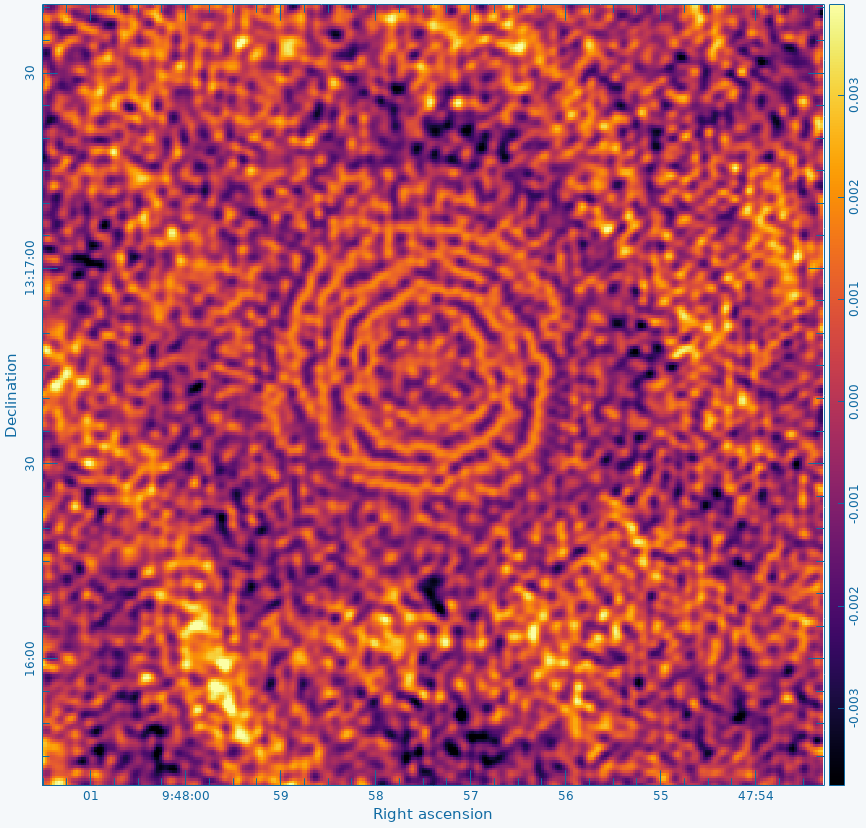

It is good practice to investigate the residuals. In this case, a significant amount of extended emission remains in the image due to the limitations of the Hogbom deconvolution (the default in `tclean`). Deconvolution algorithms such as multiscale (`deconvolver="multiscale"`) and ASP (`deconvolver="asp"` in CASA v6.5 and above) are better suited to imaging extended emission.

### Automated masking with auto-multithresh
We perform this deconvolution non-interactively using an automated masking technique called **auto-multithresh**. This algorithm works be thresholding the image based on a level determined from the sidelobe level or noise and then grows the mask outward down to a lower threshold. This procedure of iteratively growing the mask down to a lower brightness threshold on each cycle roughly mimics the way in which most users generate masks by hand: first mask bright regions and then expand the mask as those areas are CLEANed. Further information on the auto-multithresh algorithm and on tuning the parameters for optimal results can be found in this [guide](https://casaguides.nrao.edu/index.php/Automasking_Guide).

The auto-multithresh algorithm tends to require a good amount of tuning on VLA data, so it is recommended to explore parameter combinations on a small number of representative channels (here channels 22 and 23) for faster iteration. For compact VLA configurations observing extended emission, part-way between the ALMA 12m and 7m array values offer a good starting point. Due to the very large sidelobes in the PSF of this dataset, a smaller than typical `sidelobethreshold=0.5` is needed for good performance.

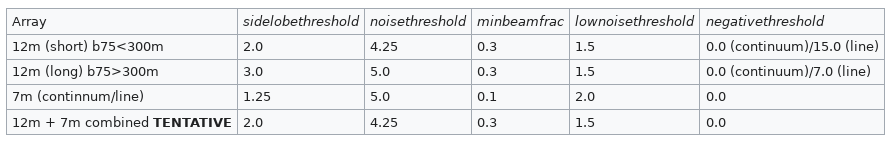

In [145]:
imagename_autom = f"{field_target}_HC3N_autom"
tasks.rmtables(tablenames=f"{imagename_autom}.*")
tasks.tclean(
    vis=vis_contsub,
    spw="1",
    imagename=imagename_autom,
    imsize=[300, 300],
    cell="0.4arcsec",
    specmode="cube",
    outframe="LSRK",
    start=19,
    nchan=1,
    restfreq=restfreq_hc3n,
    threshold=f"{1*rms:.6f}Jy",
    perchanweightdensity=True,
    pblimit=-0.001,
    weighting="briggs",
    robust=0.5,
    niter=100_000,
    interactive=False,
    # deconvolver
    deconvolver="multiscale",
    scales=[0, 5, 15],
    smallscalebias=0.5,
    # auto-multithresh
    usemask="auto-multithresh",
    noisethreshold=4.0,
    sidelobethreshold=1.0,
    minbeamfrac=0.3,
    lownoisethreshold=1.25,
    negativethreshold=1000.0,
    fastnoise=False,
);

2023-09-29 21:40:57	WARN	utils::removetable	Cannot delete file IRC+10216_HC3N_autom.mask because table is still open in another process
2023-09-29 21:40:57	WARN	utils::removetable	Cannot delete file IRC+10216_HC3N_autom.image because table is still open in another process

0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%
2023-09-29 21:48:31	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging

0%....10....20....30....40....50....60....70....80....90....100%
2023-09-29 21:48:51	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging

0%....10....20....30....40....50....60....70....80....90....100%
2023-09-29 21:49:14	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/syn

The extended scales of multiscale CLEAN provide better recovery of extended emission and reduce the severity of negative artifacts around the source.

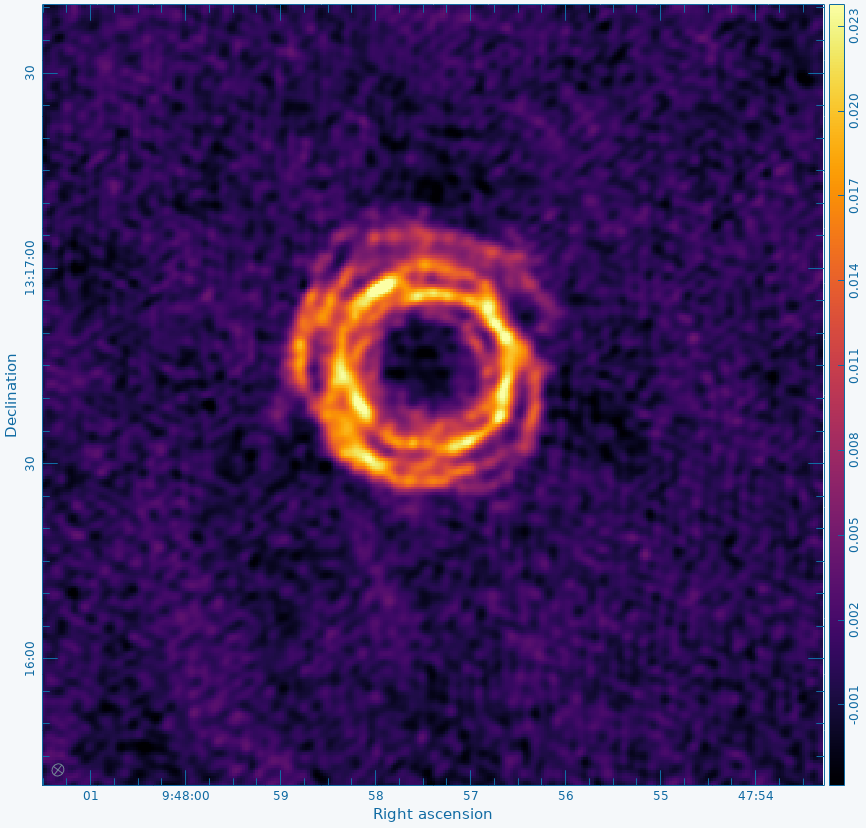

The mask generated by auto-multithresh also agrees well with what we would consider real emission from the source.

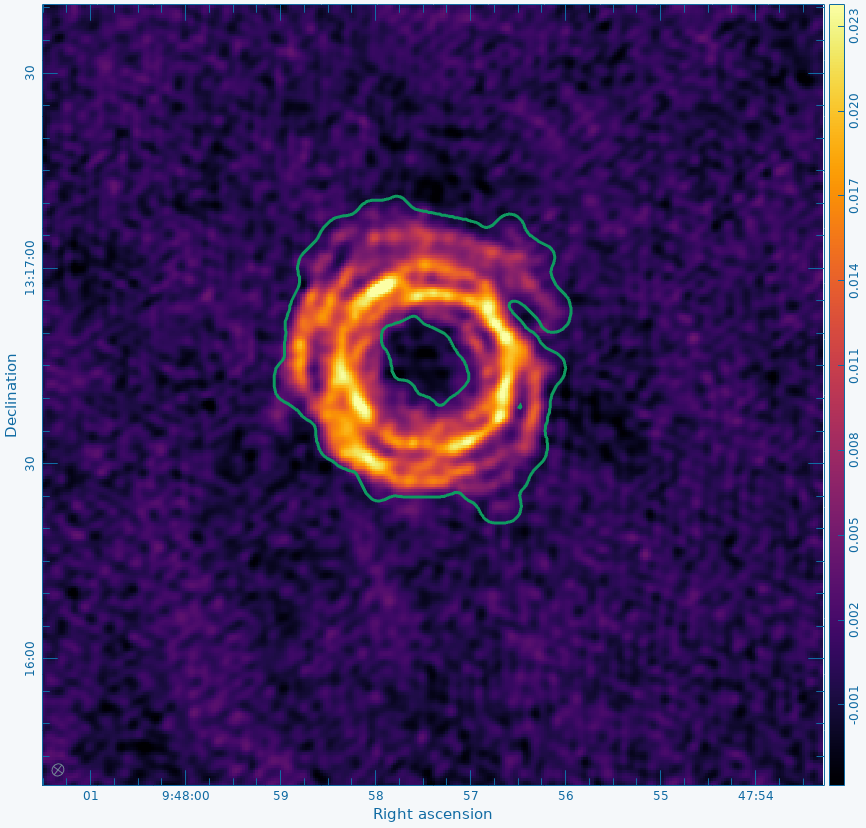

In [113]:
imagename_full = f"{field_target}_HC3N_full"
tasks.rmtables(tablenames=f"{imagename_full}.*")
tasks.tclean(
    vis=vis_contsub,
    spw="1",
    imagename=imagename_full,
    imsize=[300, 300],
    cell="0.4arcsec",
    specmode="cube",
    outframe="LSRK",
    start=1,
    nchan=-1,
    restfreq=restfreq_hc3n,
    threshold=f"{1*rms:.6f}Jy",
    perchanweightdensity=True,
    pblimit=-0.001,
    weighting="briggs",
    robust=0.5,
    niter=100_000,
    interactive=False,
    # deconvolver
    deconvolver="multiscale",
    scales=[0, 5, 15],
    smallscalebias=0.5,
    # auto-multithresh
    usemask="auto-multithresh",
    noisethreshold=4.0,
    sidelobethreshold=1.0,
    minbeamfrac=0.3,
    lownoisethreshold=1.25,
    negativethreshold=1000.0,
    fastnoise=False,
);


0%....10....20....30....40....50....60....70....80....90....100%

0%....10....20....30....40....50....60....70....80....90....100%
2023-09-27 21:30:36	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:30:37	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging

0%....10....20....30....40....50....60....70....80....90....100%
2023-09-27 21:31:48	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:32:03	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging

0%....10....20....30....4

2023-09-27 21:34:38	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging

0%....10....20....30....40....50....60....70....80....90....100%
2023-09-27 21:35:37	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:35:37	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:35:40	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:35:42	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped a

2023-09-27 21:36:54	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:36:56	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:36:56	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:36:57	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:36:57	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:36:57	WARN	SDAlg

2023-09-27 21:39:00	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:39:00	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:39:00	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:39:01	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:39:01	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:39:01	WARN	SDAlg

2023-09-27 21:40:11	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:40:11	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:40:11	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:40:11	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:40:11	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:40:11	WARN	SDAlg

2023-09-27 21:41:14	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging

0%....10....20....30....40....50....60....70....80....90....100%
2023-09-27 21:42:06	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:42:06	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:42:07	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped at large scale negative or diverging
2023-09-27 21:42:07	WARN	SDAlgorithmMSClean::takeOneStep (file src/code/synthesis/ImagerObjects/SDAlgorithmMSClean.cc, line 185)	MSClean minor cycle stopped a

## Image the continuum
Below we image the continuum by using the non-continuum subtracted meassurement set.

In [118]:
imagename_cont = f"{field_target}_HC3N_cont"
tasks.rmtables(tablenames=f"{imagename_cont}.*")
tasks.tclean(
    vis=vis_target,
    spw="0~1:3~13;46~60",
    imagename=imagename_cont,
    imsize=[300, 300],
    cell="0.4arcsec",
    specmode="mfs",
    restfreq=restfreq_hc3n,
    perchanweightdensity=True,
    pblimit=-0.001,
    deconvolver="hogbom",
    weighting="briggs",
    robust=0.5,
    niter=100_000,
    interactive=True,
);

2023-09-28 00:18:48	WARN	utils::removetable	Cannot delete file IRC+10216_HC3N_cont.image because table is still open in another process
2023-09-28 00:18:50	WARN	MSSpw Expression parser::MSSpwIndex::convertToChannelIndex (file casacore/ms/MSSel/MSSpwIndex.cc, line 400)	Channel 60 out of range for SPW 0 (valid range 0~57). Limiting it to be within the available range.
2023-09-28 00:18:50	WARN	MSSpw Expression parser::MSSpwIndex::convertToChannelIndex (file casacore/ms/MSSel/MSSpwIndex.cc, line 400)	Channel 60 out of range for SPW 0 (valid range 0~57). Limiting it to be within the available range.Channel 60 out of range for SPW 1 (valid range 0~57). Limiting it to be within the available range.
2023-09-28 00:18:50	WARN	MSSpw Expression parser::MSSpwIndex::convertToChannelIndex (file casacore/ms/MSSel/MSSpwIndex.cc, line 400)	Channel 60 out of range for SPW 0 (valid range 0~57). Limiting it to be within the available range.
2023-09-28 00:18:50	WARN	MSSpw Expression parser::MSSpwIndex::conv

## Creating moment maps
Maps of integrated intensity ("Moment 0"), intensity-weighted velocity ("Moment 1"), and intensity-weighted velocity dispersion ("Moment 2") can be generated using the [`immoments`](https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.analysis.immoments.html) task. The name "moment" derives from an analogy to statistical moments in mathematics. In CASA, the moments are defined as:

$$ M_0 = \Delta v \sum_i I_i $$
$$ M_1 = \frac{1}{M_0} \sum_i I_i v_i $$
$$ M_2 = \sqrt{\frac{1}{M_0} \sum_i I_i (v_i - M_1)^2} $$

Moment maps are especially useful for diagnostic purposes because they can collapse large 3D data cubes into 2D images which simplifies visualizing and inspecting the data. Other point estimates are helpfully included in the `immoments` task such as maximum (ID 8), minimum (ID 10), median intensity (ID 3), even though these lack any relationship to statistical moments.

In the example below we calculate Moments 0, 1, and 2 in addition to the maximum value (moment ID number 8). To avoid including excess noise in our moment calculation, which is especially problematic for Moments 1 and 2, we threshold the values to only include those above four times the RMS, as specified by the `includepix` parameter below (`1e8` is included as stand-in for infinity).

In [124]:
# We calculate Moments 0, 1, and 2 plus the maximum (8).
# Note that the warnings from the common-beam smoothing can
# safely be ignored.
tasks.immoments(
    imagename=f"{imagename_full}.image",
    moments=[0,1,2,8],
    chans="12~45",
    includepix=[4*rms, 1e8],
    outfile=imagename_full,
)

2023-09-28 00:38:41	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0798985 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2023-09-28 00:38:42	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0796681 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2023-09-28 00:38:42	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0816066 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sam

2023-09-28 00:38:51	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0782537 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2023-09-28 00:38:52	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0793909 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2023-09-28 00:38:52	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0787562 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sam

2023-09-28 00:39:01	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0804631 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2023-09-28 00:39:02	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0813238 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2023-09-28 00:39:02	WARN	immoments::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0828041 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sam

The `outfile` parameter will be used as the root name for the various moments which are written as extensions named `*.integrated`, `*.coordinate`, `*.weighted-coordinate`, and `.maximum`.

The Moment 0 map of IRC+10216 in units of Jy km/s looks like (viewed in CARTA):

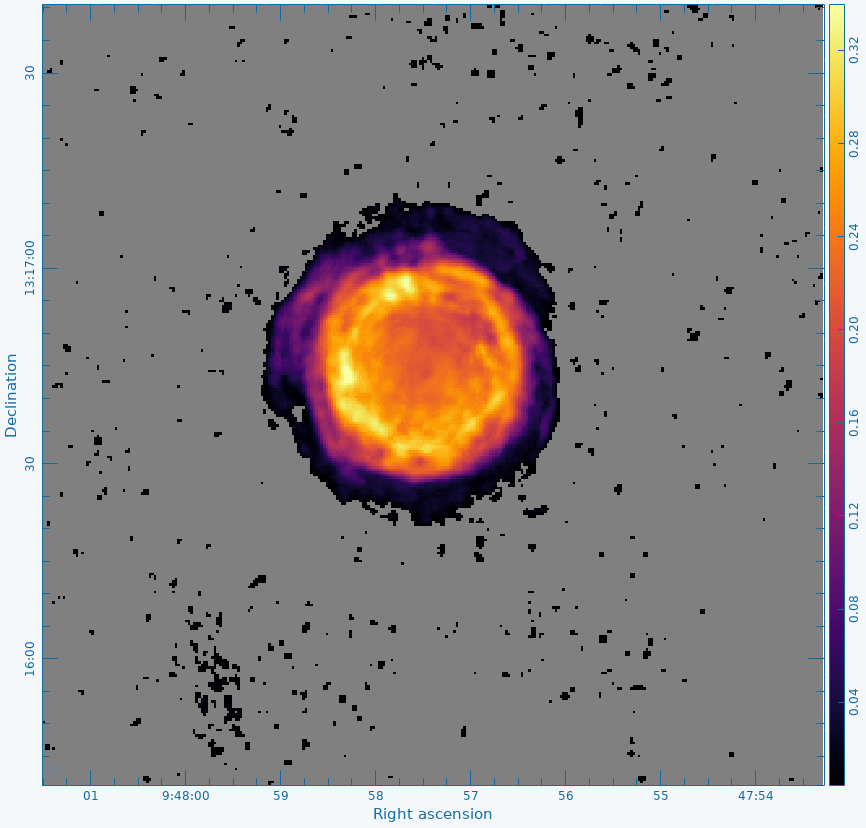

## Example analysis tasks

In [17]:
tasks.rmtables("test_pv.*")
tasks.impv(
    imagename=f"{imagename_full}.image",
    outfile="test_pv.image",
    start=[102, 123],
    end=[184, 200],
)

In [127]:
specfit_results = tasks.specfit(
    imagename=f"{imagename_full}.image",
    region="circle[[145pix, 160pix], 35pix]",
    ngauss=2,
    multifit=False,
    wantreturn=True,
)
specfit_results

{'attempted': array([[[[ True]]]]),
 'converged': array([[[[ True]]]]),
 'direction': array([[[['J2000 09:47:57.519 +13.16.44.660']]]], dtype='<U32'),
 'gs': {'amp': array([[[[[0.01941619, 0.01589377]]]]]),
  'ampErr': array([[[[[0.00127032, 0.0011166 ]]]]]),
  'center': array([[[[[-15.95840485, -37.08908341]]]]]),
  'centerErr': array([[[[[0.1852287 , 0.25742967]]]]]),
  'description': 'Gaussian singlets results',
  'fwhm': array([[[[[5.77341719, 7.47269353]]]]]),
  'fwhmErr': array([[[[[0.43618027, 0.60620057]]]]]),
  'integral': array([[[[[0.11932439, 0.12642594]]]]]),
  'integralErr': array([[[[[0.01192546, 0.01356732]]]]])},
 'ncomps': array([[[[2]]]]),
 'niter': array([[[[18]]]]),
 'succeeded': array([[[[ True]]]]),
 'type': array([[[[['GAUSSIAN', 'GAUSSIAN']]]]], dtype='<U8'),
 'valid': array([[[[ True]]]]),
 'xUnit': 'km/s',
 'yUnit': 'Jy/beam'}

In [25]:
tasks.imsmooth(
    imagename=f"{field_target}_HC3N_clean.image",
    outfile="common.image",
    kernel="common",
    overwrite=True,
)

2022-10-14 02:27:28	WARN	imsmooth::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0808209 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2022-10-14 02:27:29	WARN	imsmooth::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0819436 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2022-10-14 02:27:29	WARN	imsmooth::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0820851 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sample

2022-10-14 02:27:38	WARN	imsmooth::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0796189 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2022-10-14 02:27:38	WARN	imsmooth::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.079168 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2022-10-14 02:27:38	WARN	imsmooth::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0766801 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sampled

2022-10-14 02:27:46	WARN	imsmooth::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.0882682 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2022-10-14 02:27:47	WARN	imsmooth::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.086671 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sampled, and so the output of this application may not be what you expect. You should consider increasing the kernel size or regridding the image to a smaller pixel size
2022-10-14 02:27:47	WARN	imsmooth::Image2DConvolver::_dealWithRestoringBeam	Convolving kernel has minor axis 0.087822 arcsec which is less than the pixel diagonal length of 0.565685 arcsec. Thus, the kernel is poorly sampled,

In [26]:
tasks.specsmooth(
    imagename=f"common.image",
    outfile="smoothed.image",
    function="boxcar",
    width=3,
    overwrite=True,
)